# Boosting

Boosting은 성능이 아주 강하지 않은 모델을 여러 개 **차례대로 학습** 시키면서, 앞 단계 모델이 잘 못 맞춘 부분을 뒤 단계 모델이 조금씩 보완해 가는 앙상블 방식이다.

- 배깅(Bagging): 여러 모델을 병렬로 만들어 평균 또는 투표를 낸다.
- 부스팅(Boosting): 여러 모델을 순서대로 만들며 이전 실수를 다음 모델이 보완한다.
- 그래서 부스팅은 **틀린 부분을 계속 고쳐 가는 방식** 이라고 이해하면 쉽다.

1. 처음에는 단순한 기준으로 예측한다.
2. 현재 예측이 얼마나 틀렸는지 계산한다.
3. 그 오차를 줄이도록 다음 작은 트리를 학습한다.
4. 이 과정을 여러 번 반복해 최종 예측기를 만든다.

- 부스팅의 핵심은 이전 단계의 부족한 예측을 다음 단계가 보완한다는 점이다.
- 각 개별 트리는 약할 수 있지만, 여러 개가 순차적으로 합쳐지면 더 강한 모델이 된다.
- 순차 학습 구조이므로 보통 랜덤 포레스트보다 해석은 어렵고 학습 시간도 더 들 수 있다.
- 대신 정형 데이터에서는 매우 강력한 성능을 내는 경우가 많다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 01. GradientBoostingClassifier
- GradientBoostingClassifier는 이전 모델이 틀린 오차를 다음 모델이 보완하도록 순차적으로 학습하는 앙상블 분류 모델이다.
- 여러 개의 약한 결정트리를 단계적으로 추가하면서, 손실 함수의 기울기(오차)를 줄이는 방향으로 성능을 개선한다.
- 즉, 틀린 부분을 계속 고쳐나가며 점점 더 정확해지는 모델이다.

하이퍼파라미터
- `learning_rate`: 새 트리의 보정량을 얼마나 반영할지 결정한다. 작으면 한 번에 조금씩 고친다.
- `n_estimators`: 몇 번 보정할지 결정한다. 크면 더 많은 단계에 걸쳐 고친다.
- `max_depth`: 각 트리를 얼마나 복잡하게 만들지 결정한다. 크면 각 트리 하나하나가 더 복잡해진다.

세부 하이퍼파라미터
- `loss='log_loss'`: 분류에서 오차를 계산하는 기준이다. 예측한 클래스 확률이 실제 정답과 얼마나 차이 나는지를 반영한다.
- `subsample=1.0`: 각 단계에서 사용할 학습 샘플 비율이다. 1.0이면 전체 데이터를 모두 사용하고, 더 작게 하면 일부만 사용한다.
- `criterion='friedman_mse'`: 트리 분할 기준이다. 현재 오차를 더 잘 줄일 수 있는 방향으로 분할하도록 돕는다.
- `min_samples_split`: 노드를 한 번 더 나누기 위해 필요한 최소 샘플 수이다.
- `min_samples_leaf`: 하나의 리프 노드가 가져야 하는 최소 샘플 수이다.
- `validation_fraction`: 조기 종료 시 검증용으로 떼어둘 데이터 비율이다.
- `n_iter_no_change`: 성능 향상이 이 횟수만큼 없으면 학습을 멈춘다.
- `tol`: 성능이 이 값 이상 좋아져야 개선된 것으로 판단한다.

In [2]:
# 예제 데이터 준비
# 유방암 데이터: 이진 분류 예제
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# 학습/테스트 셋 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(455, 30) (455,)
(114, 30) (114,)


In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, log_loss

gb_clf = GradientBoostingClassifier(
    random_state=42,
    max_depth= 3,
    n_estimators=30,
    verbose=2
)

gb_clf.fit(X_train, y_train)

# 평가 
y_pred = gb_clf.predict(X_train)
print('train accuracy : ', accuracy_score(y_train,y_pred))

y_pred = gb_clf.predict(X_test)
print('test accuracy : ', accuracy_score(y_test, y_pred))


      Iter       Train Loss   Remaining Time 
         1           1.1482            1.56s
         2           1.0112            0.83s
         3           0.8948            0.57s
         4           0.8004            0.44s
         5           0.7169            0.37s
         6           0.6461            0.37s
         7           0.5840            0.32s
         8           0.5290            0.28s
         9           0.4836            0.24s
        10           0.4402            0.22s
        11           0.4027            0.19s
        12           0.3696            0.17s
        13           0.3412            0.16s
        14           0.3127            0.14s
        15           0.2885            0.13s
        16           0.2662            0.11s
        17           0.2479            0.10s
        18           0.2293            0.09s
        19           0.2116            0.08s
        20           0.1970            0.07s
        21           0.1833            0.06s
        2

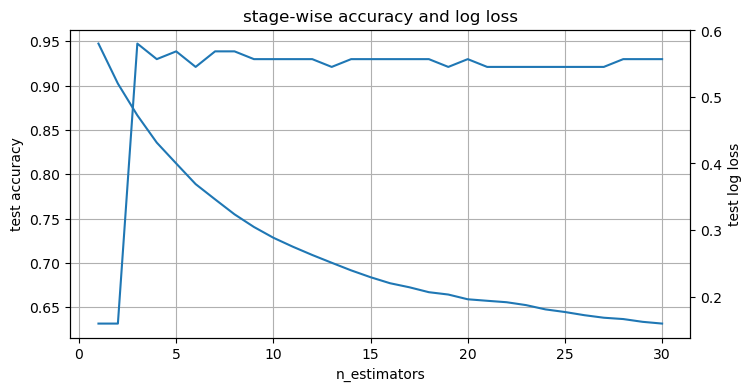

In [7]:
# 각 부스팅 단계별 테스트 정확도 확인
stage_test_acc = [
    accuracy_score(y_test, y_pred_stage)
    for y_pred_stage in gb_clf.staged_predict(X_test)
]

# 각 부스팅 단계별 테스트 log_loss 확인
# log_loss : 확률 기반의 성능 지표로 낮을 수록 좋다. (정답 클래스의 확률이 높아질수록 감소한다.)
stage_test_log_loss =[
    log_loss(y_test, y_proba_stage)
    for y_proba_stage in gb_clf.staged_predict_proba(X_test)
]

# x축 : 현재까지 사용 된 트리 개수
n_estimators_range = np.arange(1, len(stage_test_acc)+ 1)

fig, ax = plt.subplots(figsize= (8,4))

ax.plot(n_estimators_range, stage_test_acc)
ax.set_xlabel('n_estimators')
ax.set_ylabel('test accuracy')
ax.grid(True)

ax2 = ax.twinx()
ax2.plot(n_estimators_range, stage_test_log_loss)
ax2.set_ylabel('test log loss')

plt.title('stage-wise accuracy and log loss')
plt.show()

In [8]:
# 다중 분류 예제 데이터 준비
# wine 데이터는 3개 클래스를 분류하는 대표 예제이다.
from sklearn.datasets import load_wine

wine = load_wine()
X, y = wine.data, wine.target

# 클래스 분포 확인
# 각 클래스 개수가 너무 한쪽으로 치우치지 않았는지 먼저 본다.
print(np.unique(wine.target, return_counts=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(array([0, 1, 2]), array([59, 71, 48]))
(124, 13) (124,)
(54, 13) (54,)


In [ ]:
from sklearn.metrics import classification_report

# 모델 평가 (분류 리포트 확인)
y_pred = gb_clf.predict(X_train)
print('train  accuracy :', accuracy_score())

In [ ]:
# 그래프 시각화 -> x축 

stage_test_log_loss = [
    log_loss
]

In [ ]:
# 이중 분류와 동일한 아이디어로 다중 분류도 동작한다.

# 모델 학습

# 모델 평가 (분류 리포트 확인)
# 그래프 시각화


## 02. HistGradientBoostingClassifier

HistGradientBoosting은 Gradient Boosting의 아이디어는 유지하면서,
입력값을 바로 세밀하게 모두 보지 않고 먼저 여러 구간(bin)으로 묶어서 더 빠르게 학습하는 방식이다.
즉, 부스팅의 성능과 대용량 데이터에서의 효율을 함께 노린 모델이다.

- 기존 Gradient Boosting: 분할 기준을 비교적 세밀하게 탐색
- HistGradientBoosting: 값을 몇 개 구간으로 먼저 나눈 뒤 그 구간 기준으로 빠르게 탐색
- 그래서 데이터가 커질수록 속도와 메모리 측면에서 유리한 경우가 많다.

주요 특징
- 히스토그램(bin) 기반 분할로 학습 속도 향상
- 결측치 처리를 지원
- early stopping 기능을 사용해 과적합을 줄일 수 있음

하이퍼파라미터
- `max_iter`: 부스팅 반복 횟수
- `learning_rate`: 각 단계의 보정 강도
- `max_depth` 또는 `max_leaf_nodes`: 각 단계 트리 복잡도
- `max_bins`: 입력값을 몇 개 구간으로 나눌지
- `early_stopping`, `n_iter_no_change`: 성능 개선이 멈추면 조기 종료할지
- `l2_regularization`: 모델을 너무 복잡하게 만들지 않도록 제어

In [9]:
# 데이터 준비
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(455, 30) (455,)
(114, 30) (114,)


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score

hgb_clf = HistGradientBoostingClassifier(
    random_state=42,
    max_iter=5000,
    validation_fraction=0.2,            # 훈련 데이터 일부를 검증용으로 사용
    early_stopping=True,                # 검증 점수 개선이 멈추면 학습 조기 종료
    n_iter_no_change=10,                # 10번 연속 개선이 거의 없으면 중단
    verbose=2
)

hgb_clf.fit(X_train,y_train)

print('실제 반복 횟수 :', hgb_clf.n_iter_)

print('train accuracy:', hgb_clf.score(X_train, y_train))
print('test accuracy : ', hgb_clf.score(X_test, y_test))

Binning 0.000 GB of training data: 0.055 s
Binning 0.000 GB of validation data: 0.006 s
Fitting gradient boosted rounds:
[1/5000] 1 tree, 8 leaves, max depth = 4, train loss: 0.58401, val loss: 0.59066, in 0.009s
[2/5000] 1 tree, 11 leaves, max depth = 7, train loss: 0.52248, val loss: 0.53286, in 0.004s
[3/5000] 1 tree, 16 leaves, max depth = 9, train loss: 0.46696, val loss: 0.48311, in 0.007s
[4/5000] 1 tree, 15 leaves, max depth = 9, train loss: 0.42244, val loss: 0.44697, in 0.004s
[5/5000] 1 tree, 16 leaves, max depth = 7, train loss: 0.38314, val loss: 0.41401, in 0.007s
[6/5000] 1 tree, 16 leaves, max depth = 11, train loss: 0.34820, val loss: 0.37992, in 0.006s
[7/5000] 1 tree, 15 leaves, max depth = 9, train loss: 0.32026, val loss: 0.35551, in 0.004s
[8/5000] 1 tree, 16 leaves, max depth = 11, train loss: 0.29364, val loss: 0.32929, in 0.006s
[9/5000] 1 tree, 16 leaves, max depth = 10, train loss: 0.27198, val loss: 0.31040, in 0.004s
[10/5000] 1 tree, 15 leaves, max depth =

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",5000
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_d

### permutation_importance

특성 중요도를 확인하는 대표적인 방법 중 하나이다.

동작 방식
1. 이미 학습된 모델을 준비한다.
2. 특정 특성 하나의 값을 무작위로 섞는다.
3. 성능이 많이 떨어지면, 그 특성은 중요한 특성이라고 본다.

- 이 특성이 망가지면 모델이 얼마나 힘들어지는가?를 보는 방법이다.
- 값이 클수록 보통 모델이 그 특성에 더 의존하고 있었다고 해석할 수 있다.
- 단, 중요도가 높다고 해서 곧바로 인과관계가 있다고 볼 수는 없다.

In [12]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    hgb_clf,
    X_test,
    y_test,
    random_state=42,
    n_jobs=-1,
    n_repeats=5             # 한 번만 섞으면 우연이 섞일 수 있으므로 여러번 반복 후 평균 사용
)

perm_importance_df = pd.DataFrame({
    'feature' : cancer.feature_names,
    'importance' : perm_importance.importances_mean,
}). sort_values(by='importance', ascending=False)

perm_importance_df

,feature,importance
27,worst concave points,2.456140e-02
22,worst perimeter,1.578947e-02
1,mean texture,1.052632e-02
3,mean area,1.052632e-02
20,worst radius,8.771930e-03
0,mean radius,7.017544e-03
14,smoothness error,7.017544e-03
5,mean compactness,7.017544e-03
13,area error,7.017544e-03
26,worst concavity,7.017544e-03


## 03. HistGradientBoostingRegressor

연속형 값을 예측하는 회귀

- 부스팅은 분류 전용이 아니라 회귀에도 그대로 확장된다.
- 분류에서는 확률/클래스를 맞히고, 회귀에서는 연속형 수치를 맞힌다.
- 그러나 이전 단계의 오차를 다음 단계가 줄인다는 핵심 철학은 같다.

In [13]:
# 캘리포니아 주택 가격 데이터 로드
df = pd.read_csv('data/california_housing.csv')

# 데이터 구조 확인
print(df.head())
print(df.info())

# 타겟과 피처 분리
X = df.drop('MedHouseVal', axis=1).to_numpy()
y = df['MedHouseVal'].to_numpy()

# 훈련/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 no

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# - learning_rate: 한 번에 얼마나 조금씩 보정할지
# - max_depth: 각 트리를 얼마나 복잡하게 만들지
# - min_samples_leaf: 리프를 얼마나 세밀하게 나눌지
experiment_settings = [
    {
        'name': 'baseline',
        'learning_rate': 0.1,
        'max_depth': 3,
        'min_samples_leaf': 20
    },
    {
        'name': 'smaller_learning_rate',
        'learning_rate': 0.05,
        'max_depth': 3,
        'min_samples_leaf': 20
    },
    {
        'name': 'deeper_tree',
        'learning_rate': 0.1,
        'max_depth': 5,
        'min_samples_leaf': 20
    },
    {
        'name': 'smaller_leaf',
        'learning_rate': 0.1,
        'max_depth': 3,
        'min_samples_leaf': 5
    }
]

results = []

for setting in experiment_settings:
    hgb_reg = HistGradientBoostingRegressor(
        random_state=42,
        max_iter=300,
        learning_rate=setting['learning_rate'],
        max_depth=setting['max_depth'],
        min_samples_leaf=setting['min_samples_leaf'],
        validation_fraction=0.1,
        n_iter_no_change=20,
        early_stopping=True,
        verbose=0
    )

    hgb_reg.fit(X_train, y_train)

    y_train_pred = hgb_reg.predict(X_train)
    y_test_pred = hgb_reg.predict(X_test)

    results.append({
        'model': setting['name'],
        'learning_rate': setting['learning_rate'],
        'max_depth': setting['max_depth'],
        'min_samples_leaf': setting['min_samples_leaf'],
        'train_mse': mean_squared_error(y_train, y_train_pred),
        'train_r2': r2_score(y_train, y_train_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'test_r2': r2_score(y_test, y_test_pred)
    })

results_df = pd.DataFrame(results).sort_values(by='test_r2', ascending=False)
results_df

,model,learning_rate,max_depth,min_samples_leaf,train_mse,train_r2,test_mse,test_r2
2,deeper_tree,0.10,5,20,0.130148,0.902640,0.208617,0.840800
0,baseline,0.10,3,20,0.206638,0.845421,0.243938,0.813846
3,smaller_leaf,0.10,3,5,0.202873,0.848238,0.244279,0.813585
1,smaller_learning_rate,0.05,3,20,0.242450,0.818631,0.271597,0.792739


## 04. 정리
1. Boosting은 이전 단계의 오차를 다음 단계가 순차적으로 보완해 가는 앙상블 방식이다.
2. GradientBoosting은 작은 결정트리를 여러 번 추가하며, 틀린 부분을 계속 줄여 가는 대표적인 부스팅 모델이다.
3. HistGradientBoosting은 값을 구간(bin)으로 나누어 처리하여, 기존 Gradient Boosting보다 더 빠르고 효율적으로 학습할 수 있다.
4. 분류에서는 클래스 예측 성능을 높이고, 회귀에서는 연속형 값을 더 정교하게 예측하도록 확장할 수 있다.
5. 부스팅은 정형 데이터에서 매우 강력한 성능을 내지만, 트리 깊이·학습률·반복 횟수를 크게 하면 과적합에 주의해야 한다.
6. 따라서 learning_rate, max_depth, min_samples_leaf, early stopping 같은 설정을 함께 보며 일반화 성능을 확인하는 것이 중요하다.